# Customer Churn — EDA, Data Cleaning & Model Training

**AI Engineer assessment · Stage 1 notebook**

This notebook is self-contained (runs on Google Colab: upload `CustomerChurn.csv`
next to it or adjust `DATA_PATH`). The production versions of the cleaning and
model code live in `src/data_prep.py` and `src/model/churn_model.py` in the repo —
this notebook documents *why* each decision was made and shows the evidence.

**Contents**
1. Load & first look
2. Data-quality investigation — what's actually wrong with this file
3. Cleaning decisions (with justification)
4. Exploratory analysis — what drives churn
5. Model training & selection (stratified CV)
6. Metric choice & threshold — the reasoning
7. Final evaluation + example of the callable interface

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 30)
DATA_PATH = next(p for p in ['data/raw/CustomerChurn.csv', 'CustomerChurn.csv',
                             '../data/raw/CustomerChurn.csv'] if Path(p).exists())
raw = pd.read_csv(DATA_PATH)
print(raw.shape)
raw.head(3)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Data-quality investigation

The brief says the dataset has problems but doesn't say what they are. So: check
dtypes, missing values, blank strings, duplicates, category consistency, numeric
ranges, and internal consistency between related columns.

In [2]:
print(raw.dtypes, end='\n\n')
print('NaNs per column (default parse):', raw.isna().sum().sum())
print('duplicate rows:', raw.duplicated().sum(),
      '| duplicate customerIDs:', raw['customerID'].duplicated().sum())

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

NaNs per column (default parse): 0
duplicate rows: 0 | duplicate customerIDs: 0


**Finding 1 — `TotalCharges` is text, not a number.** No NaNs anywhere, yet a
charges column parsed as `object`. Something non-numeric is hiding in it:

In [3]:
tc = pd.to_numeric(raw['TotalCharges'].astype(str).str.strip(), errors='coerce')
bad = raw[tc.isna()]
print(f'{len(bad)} rows have a blank (single space) TotalCharges')
bad[['customerID','tenure','MonthlyCharges','TotalCharges','Churn']]

11 rows have a blank (single space) TotalCharges


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


All 11 problem rows have **`tenure == 0`** — these are brand-new customers who
have not been billed yet. The blank is not random missingness; it *means* "nothing
billed so far". That drives the imputation choice below (0, not the mean — mean
imputation would invent ~$2,280 of spend for people who have paid nothing).

**Finding 2 — inconsistent encoding of `SeniorCitizen`.** Every other binary
column is Yes/No; this one is 0/1. Harmless for a model, confusing for EDA and
for an agent answering natural-language questions, so it gets recoded.

In [4]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
print({c: sorted(raw[c].unique()) for c in binary_cols})
print('SeniorCitizen:', sorted(raw['SeniorCitizen'].unique()))

{'Partner': ['No', 'Yes'], 'Dependents': ['No', 'Yes'], 'PhoneService': ['No', 'Yes'], 'PaperlessBilling': ['No', 'Yes'], 'Churn': ['No', 'Yes']}
SeniorCitizen: [np.int64(0), np.int64(1)]


**Finding 3 — structurally redundant category levels.** Six service columns have a
third level `"No internet service"` which is fully determined by
`InternetService == 'No'` (same story for `"No phone service"` vs `PhoneService`).
Verified below — the redundancy is *perfect*, so for modelling these collapse to
`"No"` (keeping them would just duplicate the InternetService signal one-hot-wise).

In [5]:
svc = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
       'StreamingTV','StreamingMovies']
for c in svc:
    n_no_int = (raw[c] == 'No internet service').sum()
    match = ((raw[c] == 'No internet service') == (raw['InternetService'] == 'No')).all()
    print(f'{c:18s} "No internet service" rows: {n_no_int}  perfectly aligned: {match}')
print('MultipleLines vs PhoneService aligned:',
      ((raw['MultipleLines']=='No phone service') == (raw['PhoneService']=='No')).all())

OnlineSecurity     "No internet service" rows: 1526  perfectly aligned: True
OnlineBackup       "No internet service" rows: 1526  perfectly aligned: True
DeviceProtection   "No internet service" rows: 1526  perfectly aligned: True
TechSupport        "No internet service" rows: 1526  perfectly aligned: True
StreamingTV        "No internet service" rows: 1526  perfectly aligned: True
StreamingMovies    "No internet service" rows: 1526  perfectly aligned: True
MultipleLines vs PhoneService aligned: True


**Finding 4 — class imbalance.** 26.5% churn. Not a data *error*, but it dictates
the metric and threshold choices in section 6.

**Checked and found clean:** no duplicate rows/IDs, no whitespace/case variants in
categories, numeric ranges sane (tenure 0–72, MonthlyCharges 18.25–118.75, no
negatives). `TotalCharges ≈ tenure × MonthlyCharges` holds within 50% for all but
2 rows (plausible mid-life plan changes — left untouched).

In [6]:
print(raw['Churn'].value_counts(normalize=True).round(4))
ten = raw['tenure']; mc = raw['MonthlyCharges']
dev = (tc - ten*mc).abs() / (ten*mc).replace(0, np.nan)
print('rows deviating >50% from tenure*MonthlyCharges:', int((dev > .5).sum()))

Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64
rows deviating >50% from tenure*MonthlyCharges: 2


## 3. Cleaning decisions

| # | Issue | Decision | Why |
|---|-------|----------|-----|
| 1 | 11 blank `TotalCharges` | coerce to numeric, **impute 0**, add `NewCustomer` flag | blank = unbilled new customer; 0 is the true amount billed; flag preserves the information |
| 2 | `SeniorCitizen` 0/1 | recode Yes/No | consistency with every other flag |
| 3 | "No internet/phone service" levels | collapse to "No" **in the model view only** | perfectly redundant with the carrier columns; kept in the analytics view for EDA fidelity |
| 4 | imbalance | handled via metric/threshold, not resampling | resampling distorts calibrated probabilities we want to expose as "risk" |

In [7]:
def clean(df):
    out = df.copy()
    t = pd.to_numeric(out['TotalCharges'].astype(str).str.strip(), errors='coerce')
    out['NewCustomer'] = ((t.isna()) & (out['tenure']==0)).map({True:'Yes', False:'No'})
    out['TotalCharges'] = t.fillna(0.0)
    if pd.api.types.is_numeric_dtype(out['SeniorCitizen']):
        out['SeniorCitizen'] = out['SeniorCitizen'].map({0:'No', 1:'Yes'})
    for c in out.columns:
        if out[c].dtype == object or pd.api.types.is_string_dtype(out[c]):
            out[c] = out[c].str.strip()
    return out

def model_view(df):
    out = df.copy()
    for c in svc: out[c] = out[c].replace({'No internet service':'No'})
    out['MultipleLines'] = out['MultipleLines'].replace({'No phone service':'No'})
    return out

df = clean(raw)
assert df['TotalCharges'].isna().sum() == 0 and df['customerID'].is_unique
print('clean:', df.shape, '| churn rate:', round((df.Churn=='Yes').mean(), 4))

clean: (7043, 22) | churn rate: 0.2654


## 4. Exploratory analysis — what drives churn

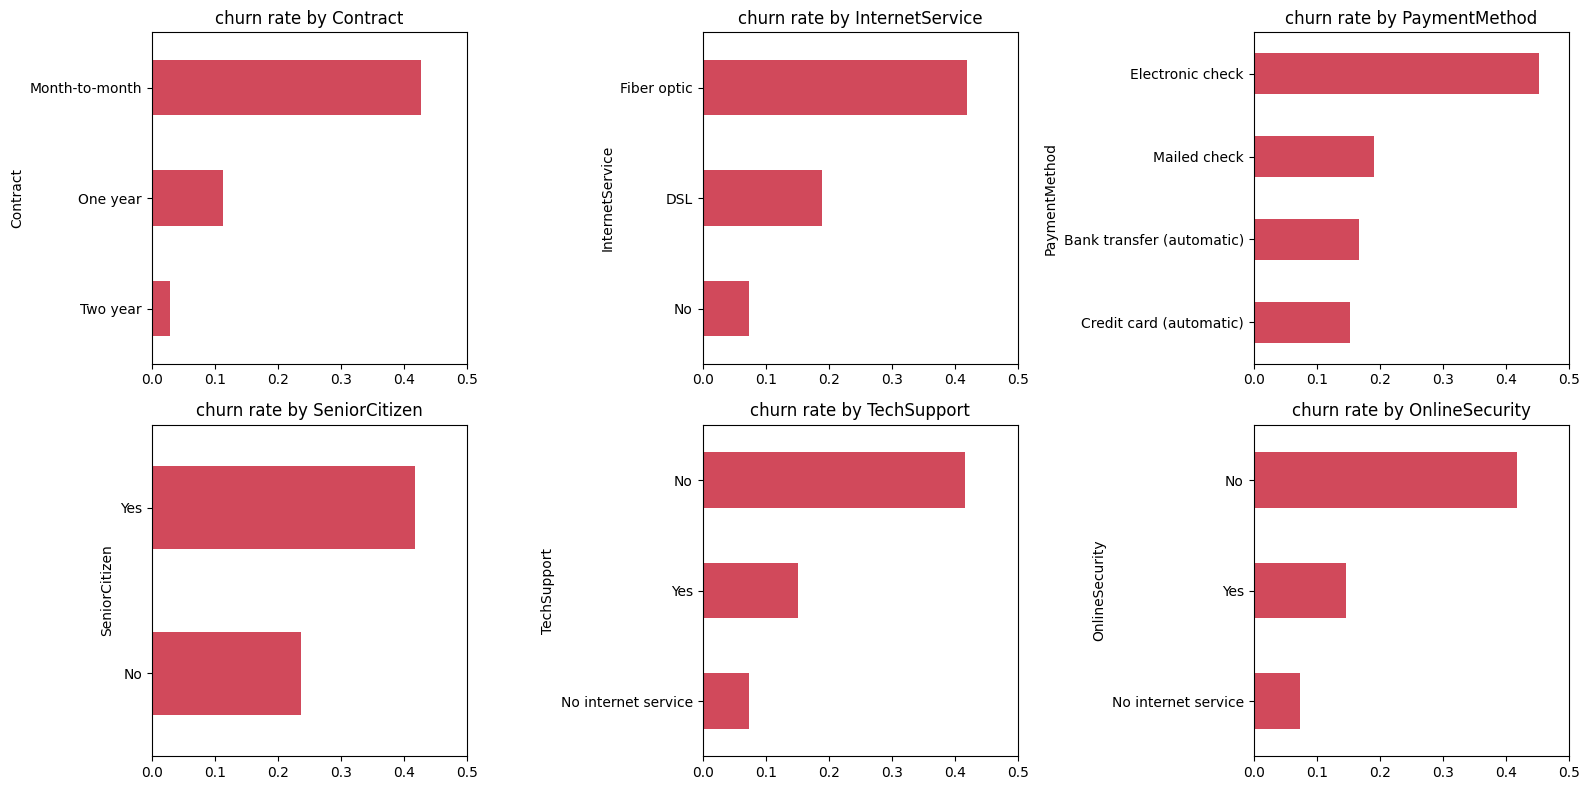

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
def rate_plot(ax, col):
    r = df.groupby(col)['Churn'].apply(lambda s: (s=='Yes').mean()).sort_values()
    r.plot.barh(ax=ax, color='#d1495b'); ax.set_title(f'churn rate by {col}')
    ax.set_xlim(0, .5); ax.set_xlabel('')
for ax, col in zip(axes.flat, ['Contract','InternetService','PaymentMethod',
                               'SeniorCitizen','TechSupport','OnlineSecurity']):
    rate_plot(ax, col)
plt.tight_layout(); plt.show()

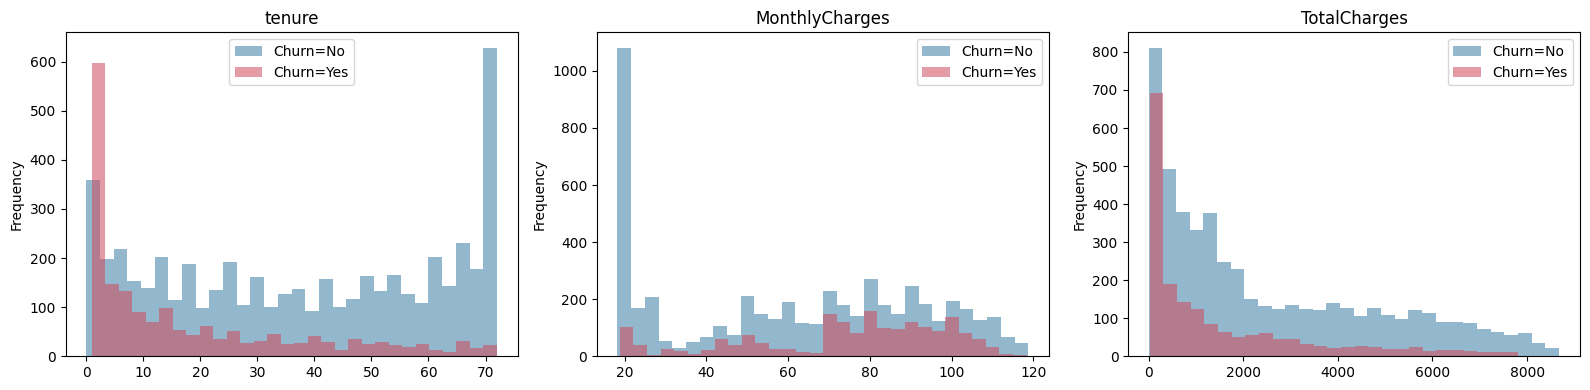

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['tenure','MonthlyCharges','TotalCharges']):
    for churn, color in [('No','#3a7ca5'), ('Yes','#d1495b')]:
        df.loc[df.Churn==churn, col].plot.hist(ax=ax, bins=30, alpha=.55,
                                               color=color, label=f'Churn={churn}')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

Read: churn concentrates in **month-to-month contracts, fiber-optic internet,
electronic-check payers, early tenure, higher monthly charges**, and customers
*without* tech support / online security. Two-year contracts and long tenure are
strongly protective. This is exactly the structure the model should find, and it
gives us sanity checks for the agent later (e.g. a "what if this customer moved to
a two-year contract" query should project risk *down*).

## 5. Model training & selection

Pipeline = one-hot(categoricals) + standardize(numerics) → classifier, so no
preprocessing leaks outside CV folds. Three sensible candidates compared with
**stratified 5-fold CV on the training split only** (the 20% validation split
stays untouched until threshold/final evaluation).

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

dfm = model_view(df)
cat = ['gender','SeniorCitizen','Partner','Dependents','PhoneService',
       'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
       'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
       'Contract','PaperlessBilling','PaymentMethod']
num = ['tenure','MonthlyCharges','TotalCharges']
X, y = dfm[cat+num], (dfm['Churn']=='Yes').astype(int)
Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)

prep = lambda: ColumnTransformer([('c', OneHotEncoder(handle_unknown='ignore'), cat),
                                  ('n', StandardScaler(), num)])
candidates = {
    'logistic_regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'random_forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=4,
                                            class_weight='balanced', random_state=42, n_jobs=-1),
    'gradient_boosting': GradientBoostingClassifier(random_state=42),
}
cv = StratifiedKFold(5, shuffle=True, random_state=42)
for name, est in candidates.items():
    pipe = Pipeline([('p', prep()), ('m', est)])
    ap  = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring='average_precision', n_jobs=-1)
    roc = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:22s} PR-AUC {ap.mean():.4f} ± {ap.std():.4f}   ROC-AUC {roc.mean():.4f}')

logistic_regression    PR-AUC 0.6601 ± 0.0199   ROC-AUC 0.8459


random_forest          PR-AUC 0.6502 ± 0.0224   ROC-AUC 0.8424


gradient_boosting      PR-AUC 0.6651 ± 0.0190   ROC-AUC 0.8473


## 6. Metric choice — the reasoning

**Primary metric: PR-AUC (average precision). Threshold metric: F2.**

* **Accuracy is out.** Predicting "nobody churns" scores 73.5% accuracy and is
  useless. With 26.5% positives, accuracy mostly measures the majority class.
* **Why PR-AUC over ROC-AUC as the primary?** ROC-AUC counts true-negative
  performance, which is inflated by the large majority class; PR-AUC evaluates
  ranking quality *specifically on the churners* — precisely what a retention
  team consuming "risk scores" cares about. ROC-AUC is still reported (it's the
  conventional comparable number).
* **Why a threshold tuned for F2?** The costs are asymmetric: a missed churner
  loses a customer's lifetime value; a false alarm costs a discount offer.
  Recall is worth more than precision — F2 encodes "recall matters ~2× more".
  This is a business judgement, stated explicitly rather than hidden behind the
  0.5 default. The chosen threshold trades ~58% flagged-customer volume for
  ~94% churner coverage — the right trade if outreach is cheap (email/discount),
  and easily re-tuned to F1 if outreach were expensive.
* The model's *probability* is what the agent exposes as `risk_score`; the
  threshold only drives the binary `would_flag_as_churn` field.

In [11]:
from sklearn.metrics import (average_precision_score, roc_auc_score, fbeta_score,
                             precision_score, recall_score, classification_report)
best = Pipeline([('p', prep()), ('m', GradientBoostingClassifier(random_state=42))])
best.fit(Xtr, ytr)
proba = best.predict_proba(Xval)[:, 1]

grid = np.linspace(.05, .95, 181)
f2s = [fbeta_score(yval, proba >= t, beta=2) for t in grid]
thr = float(grid[int(np.argmax(f2s))])
print(f'validation PR-AUC : {average_precision_score(yval, proba):.4f}')
print(f'validation ROC-AUC: {roc_auc_score(yval, proba):.4f}')
print(f'F2-optimal threshold: {thr:.3f}')
print(f'  recall    @thr: {recall_score(yval, proba>=thr):.3f}')
print(f'  precision @thr: {precision_score(yval, proba>=thr):.3f}')
print()
print(classification_report(yval, proba >= thr, target_names=['stay','churn']))

validation PR-AUC : 0.6583
validation ROC-AUC: 0.8433
F2-optimal threshold: 0.105
  recall    @thr: 0.941
  precision @thr: 0.416

              precision    recall  f1-score   support

        stay       0.96      0.52      0.68      1035
       churn       0.42      0.94      0.58       374

    accuracy                           0.63      1409
   macro avg       0.69      0.73      0.63      1409
weighted avg       0.82      0.63      0.65      1409



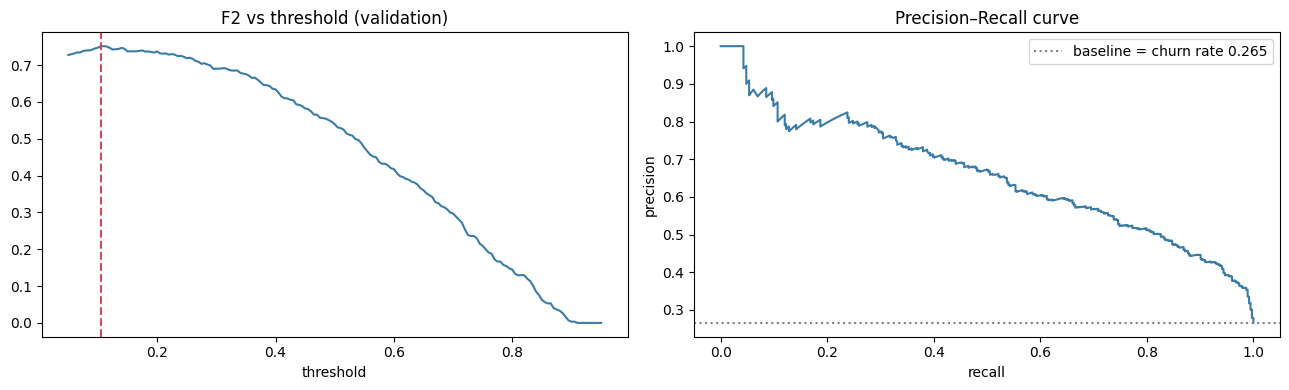

In [12]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(grid, f2s, color='#3a7ca5'); a1.axvline(thr, color='#d1495b', ls='--')
a1.set_title('F2 vs threshold (validation)'); a1.set_xlabel('threshold')
from sklearn.metrics import precision_recall_curve
p, r, _ = precision_recall_curve(yval, proba)
a2.plot(r, p, color='#3a7ca5'); a2.axhline(yval.mean(), color='gray', ls=':',
        label=f'baseline = churn rate {yval.mean():.3f}')
a2.set_title('Precision–Recall curve'); a2.set_xlabel('recall'); a2.set_ylabel('precision')
a2.legend(); plt.tight_layout(); plt.show()

## 7. The callable interface (what the agent uses)

The production artifact (`artifacts/churn_model.joblib`, built by
`python -m scripts.train`) wraps the refit-on-all-data pipeline as:

```python
model.predict_churn_risk(customer_id) -> {risk_score, risk_band, top_factors, ...}
model.what_if(customer_id, {"Contract": "Two year"})   # projected risk
model.predict_hypothetical({...partial features...})   # new data points
model.score_frame(df)                                  # vectorised, for segments
```

`top_factors` are baseline-substitution attributions: replace one feature with the
dataset baseline (mode/median), measure the risk delta. Model-agnostic and cheap.
Demo below re-creates it inline for one high-risk-looking validation customer:

In [13]:
row = Xval.iloc[[int(np.argmax(proba))]]
base = float(best.predict_proba(row)[0, 1])
baselines = {c: dfm[c].mode()[0] for c in cat} | {c: float(dfm[c].median()) for c in num}
impacts = []
for f in cat + num:
    r2 = row.copy(); r2[f] = baselines[f]
    if r2[f].iloc[0] != row[f].iloc[0]:
        impacts.append((f, row[f].iloc[0], round(base - float(best.predict_proba(r2)[0,1]), 4)))
impacts.sort(key=lambda t: abs(t[2]), reverse=True)
print(f'risk_score = {base:.4f}  (highest-scored validation customer)')
print('top factors (feature, value, +risk vs baseline):')
for f, v, d in impacts[:5]: print(f'  {f:18s} {str(v):15s} {d:+.4f}')

risk_score = 0.9093  (highest-scored validation customer)
top factors (feature, value, +risk vs baseline):
  tenure             1               +0.2262
  TotalCharges       95.45           +0.0427
  MonthlyCharges     95.45           +0.0348
  MultipleLines      Yes             +0.0280
  StreamingTV        Yes             +0.0061


**Takeaway.** Gradient boosting wins on PR-AUC (0.665 CV / ~0.66 holdout,
ROC-AUC ~0.84 — solidly in the published range for this dataset). The model's
top risk drivers match the EDA story (contract type, tenure, fiber optic,
charges), which is the consistency the agent's answers rely on.